In [9]:
import sys
!{sys.executable} -m pip install ipython-sql sqlalchemy

  Obtaining dependency information for ipython-sql from https://files.pythonhosted.org/packages/30/8f/9e50fa53ffc371483f9d1b90c1175b706d28a2e978e90a8894035af01905/ipython_sql-0.5.0-py3-none-any.whl.metadata
  Obtaining dependency information for prettytable from https://files.pythonhosted.org/packages/ee/8c/83087ebc47ab0396ce092363001fa37c17153119ee282700c0713a195853/prettytable-3.17.0-py3-none-any.whl.metadata
  Obtaining dependency information for sqlalchemy from https://files.pythonhosted.org/packages/93/5f/e081490f8523adc0088f777e4ebad3cac21e498ec8a3d4067074e21447a1/sqlalchemy-2.0.46-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for sqlparse from https://files.pythonhosted.org/packages/49/4b/359f28a903c13438ef59ebeee215fb25da53066db67b305c125f1c6d2a25/sqlparse-0.5.5-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   - -------------------------------------- 0.1/2.1 MB 3.0 MB/s eta 0:00:01
   ------- -------------

In [11]:
%load_ext sql
%sql sqlite://  

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


Sample Tests with Triple A games:
Counter-Strike 2 (8,815,087 reviews, 150,000,000 owners):
-------Game score: 0.8283147727252075
Positive ratio: 0.8669
Review rate: 1 in 17
--------------------------------------------------
Clair Obscur: Expedition 33 (111,032 reviews, 3,500,000 owners):
-------Game score: 0.8801111919172966
Positive ratio: 0.9566
Review rate: 1 in 32
--------------------------------------------------
Cyberpunk 2077 (844,921 reviews, 35,000,000 owners):
-------Game score: 0.774108517937398
Positive ratio: 0.8439
Review rate: 1 in 41
--------------------------------------------------
Hollow Knight (415,946 reviews, 7,500,000 owners):
-------Game score: 0.9185966503123926
Positive ratio: 0.9704
Review rate: 1 in 18
--------------------------------------------------
Red Dead Redemption 2 (733,542 reviews, 15,000,000 owners):
-------Game score: 0.8712229442225494
Positive ratio: 0.9225
Review rate: 1 in 20
--------------------------------------------------


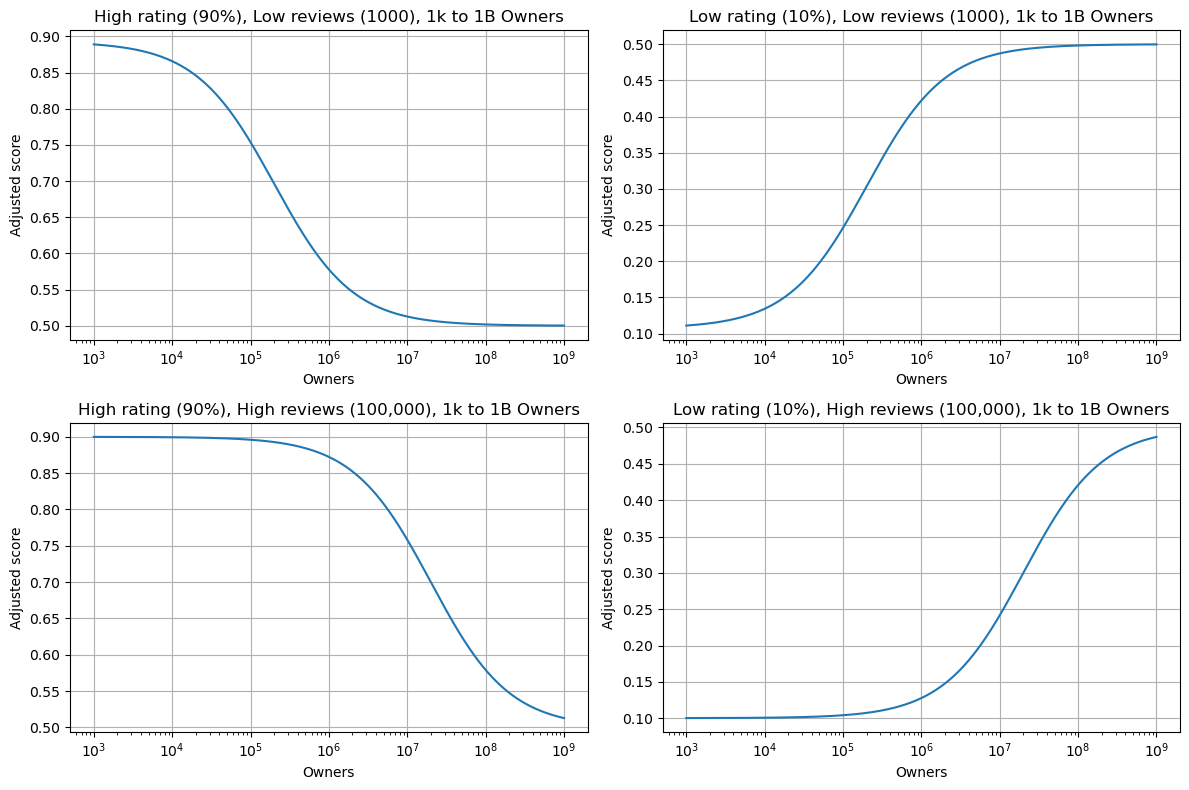

CPU times: total: 8.06 s
Wall time: 8.49 s


In [1]:
%%time

import math
import numpy as np
import matplotlib.pyplot as plt

#----Confidence Weighted Sigmoid Functions----#

# S-Curve Sigmoid
def sigmoid(t):
    return 1 / (1 + math.exp(-t))

# Main func. q0 and n0 are threshold, adjust to change behaviour, k and k2 are curve ramp constants.
def user_score(pos, neg, owners, q0=0.005, n0=10, k=2, k2=2):

    # Total Reviews
    n = pos + neg
    if n <= 0 or owners <= 1:
        return float("nan")

    # Raw User Score (Ratio of Pos to All Reviews)
    p = pos / n
    # Ratio of Reviews to Owners
    q = n / owners

    '''Confident Weight Formula
        First sigmoid - Weighting for review ratio, compared to defined threshold
        Second sigmoid - Weighting for review count, compared to defined threshold'''
    w = sigmoid(k * (math.log10(q) - math.log10(q0))) * \
        sigmoid(k2 * (math.log10(n) - math.log10(n0)))

    return 0.5 + (p - 0.5) * w

def show(game, pos, neg, owners):
    total = pos + neg
    pos_ratio = pos / total
    review_rate = total / owners

    print(f"{game} ({total:,} reviews, {owners:,} owners):")
    print("-------Game score:", user_score(pos, neg, owners))
    print("Positive ratio:", round(pos_ratio, 4))
    print("Review rate: 1 in", round(1 / review_rate))
    print("-" * 50)

print("Sample Tests with Triple A games:")
# Note: Counter Strike 2 displays reviews for CS2 solely on steam, but the webapi fetches the
# reviews for the appid 730 which also includes CS:GO from before migration.
show("Counter-Strike 2", 7_642_084, 1_173_003, 150_000_000)

show("Clair Obscur: Expedition 33", 106_216, 4_816, 3_500_000)

show("Cyberpunk 2077", 713_071, 131_850, 35_000_000)

show("Hollow Knight", 403_641, 12_305, 7_500_000)

show("Red Dead Redemption 2", 676_667, 56_875, 15_000_000)




owners = np.logspace(3, 9, 1000)   # 1k -> 1B owners
cases = [
    (900, 100, "High rating (90%), Low reviews (1000), 1k to 1B Owners"),
    (100, 900, "Low rating (10%), Low reviews (1000), 1k to 1B Owners"),
    (90_000, 10_000, "High rating (90%), High reviews (100,000), 1k to 1B Owners"),
    (10_000, 90_000, "Low rating (10%), High reviews (100,000), 1k to 1B Owners"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (pos, neg, title) in zip(axes.flat, cases):
    scores = [user_score(pos, neg, o) for o in owners]

    ax.plot(owners, scores)
    ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel("Owners")
    ax.set_ylabel("Adjusted score")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [15]:
%config SqlMagic.style = 'SINGLE_BORDER'

In [22]:
%%time
import csv
import sqlite3


# Step 1: Fix the CSV (same as before)
with open('games.csv', 'r', encoding='utf-8') as f:
    lines = f.readlines()
lines[0] = lines[0].replace('DiscountDLC count', 'Discount,DLC count')
with open('games.csv', 'w', encoding='utf-8') as f:
    f.writelines(lines)

# Step 2: Connect ipython-sql to a FILE database (not in-memory)
%sql sqlite:///games.db


conn = sqlite3.connect("games.db")
cursor = conn.cursor()

with open('games.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    columns = reader.fieldnames
    
    # Create table
    col_defs = ", ".join([f'"{col}" TEXT' for col in columns])
    cursor.execute(f"DROP TABLE IF EXISTS games")
    cursor.execute(f"CREATE TABLE games ({col_defs})")
    
    # Insert all rows
    placeholders = ", ".join(["?" for _ in columns])
    rows = [tuple(row[col] for col in columns) for row in reader]
    
    for row in rows:
        cursor.execute(f'INSERT INTO games VALUES ({placeholders})', row)

    conn.commit()

print("Done! Rows loaded:", cursor.execute("SELECT COUNT(*) FROM games").fetchone()[0])



Done! Rows loaded: 122611
CPU times: total: 23.9 s
Wall time: 44.4 s


In [23]:
%%time

cursor.execute("""
    UPDATE games
    SET "Estimated owners" = CASE "Estimated owners"
        WHEN '0 - 0'                   THEN '0'
        WHEN '0 - 20000'               THEN '10000'
        WHEN '20000 - 50000'           THEN '35000'
        WHEN '50000 - 100000'          THEN '75000'
        WHEN '100000 - 200000'         THEN '150000'
        WHEN '200000 - 500000'         THEN '350000'
        WHEN '500000 - 1000000'        THEN '750000'
        WHEN '1000000 - 2000000'       THEN '1500000'
        WHEN '2000000 - 5000000'       THEN '3500000'
        WHEN '5000000 - 10000000'      THEN '7500000'
        WHEN '10000000 - 20000000'     THEN '15000000'
        WHEN '20000000 - 50000000'     THEN '35000000'
        WHEN '50000000 - 100000000'    THEN '75000000'
        WHEN '100000000 - 200000000'   THEN '150000000'
    END
    WHERE "Estimated owners" IN (
        '0 - 0', '0 - 20000', '20000 - 50000', '50000 - 100000',
        '100000 - 200000', '200000 - 500000', '500000 - 1000000',
        '1000000 - 2000000', '2000000 - 5000000', '5000000 - 10000000',
        '10000000 - 20000000', '20000000 - 50000000',
        '50000000 - 100000000', '100000000 - 200000000'
    )
""")
conn.commit()

cursor.execute("""
    SELECT "Estimated owners", COUNT(*) as count
    FROM games
    GROUP BY "Estimated owners"
    ORDER BY count DESC
""")

for row in cursor.fetchall():
    print(row)

('10000', 75404)
('0', 21641)
('35000', 11396)
('75000', 5355)
('150000', 3454)
('350000', 2853)
('750000', 1154)
('1500000', 729)
('3500000', 405)
('7500000', 125)
('15000000', 51)
('35000000', 31)
('75000000', 9)
('150000000', 4)
CPU times: total: 7.41 s
Wall time: 12.6 s


In [27]:
%%time

cursor.execute("""
    CREATE TABLE games_slim AS
    SELECT Name, Positive, Negative, "Estimated owners"
    FROM games
""")

cursor.execute("DROP TABLE games")
cursor.execute("ALTER TABLE games_slim RENAME TO games")
conn.commit()

cursor.execute("""
    DELETE FROM games
    WHERE CAST(Positive AS INTEGER) <= 1000
""")
conn.commit()

CPU times: total: 15.6 ms
Wall time: 26.8 ms


In [33]:
%%time

# Register the function with SQLite
conn.create_function("user_score", 3, lambda pos, neg, owners: user_score(int(pos), int(neg), int(owners)))

cursor.execute("""
    SELECT Name, Positive, Negative, "Estimated owners" 
    FROM games 
""")
rows = cursor.fetchall()

# Add the score column
cursor.execute("ALTER TABLE games ADD COLUMN score REAL")

# Process each row slowly with a new connection each time
for row in rows:
    name, pos, neg, owners = row
    
    # Calculate score in Python
    score = user_score(int(pos), int(neg), int(owners))
    
    # Open a brand new connection for every single row (wasteful)
    conn2 = sqlite3.connect("games.db")
    cur2 = conn2.cursor()
    
    cur2.execute("""
        UPDATE games 
        SET score = ? 
        WHERE Name = ?
    """, (score, name))
    
    conn2.commit()
    conn2.close()

CPU times: total: 29.9 s
Wall time: 46.3 s


In [30]:
%%time

cursor.execute("""
    SELECT 
        Name,
        Positive,
        Negative,
        "Estimated owners",
        user_score(Positive, Negative, "Estimated owners") AS score
    FROM games
    ORDER BY score DESC
    LIMIT 20
""")

for row in cursor.fetchall():
    print(row)

('Portal 2', '153381', '2059', '10000', 0.9861924721042887)
('Portal', '56620', '1154', '10000', 0.9787197739422129)
('星空列车与白的旅行', '5265', '66', '35000', 0.9617913366488704)
("Sid Meier's Civilization® V", '134711', '5726', '10000', 0.9586489979944823)
('Trine 2: Complete Story', '16882', '733', '10000', 0.9549033245080707)
('The Test: Hypothesis Rising', '5758', '135', '35000', 0.9538322919209521)
('Knights College', '1995', '58', '10000', 0.949336759629589)
('Smile For Me', '2691', '96', '10000', 0.9484340691376987)
('Snail Simulator', '1119', '16', '10000', 0.9482923280178854)
('Touhou Kanjuden ~ Legacy of Lunatic Kingdom.', '1318', '26', '10000', 0.9482406674844308)
('planetarian HD', '2947', '34', '35000', 0.9470599570748086)
('Cats Organized Neatly', '4307', '105', '35000', 0.9467315664671692)
('Batman: Arkham Asylum Game of the Year Edition', '21567', '916', '75000', 0.945957728373009)
('Cassette Beasts', '8828', '470', '10000', 0.9435283767300209)
('Majotori', '1844', '65', '10